# Trend-Based Recovery Time — Regional Level by Category & Flow Type

This notebook decomposes regional mobility into **three flow types** and measures
recovery for each independently:

1. **Within-region $W(t,c)$:** Trips where BOTH origin AND destination are in the
   affected region $A$.  
   $W(t) = \sum_{o\in A}\sum_{d\in A} M(t,d,o)$  
   *Captures local functioning — internal circulation, local services operating.*

2. **Outflow $O(t,c)$:** Trips FROM $A$ TO outside.  
   $O(t) = \sum_{o\in A}\sum_{d\notin A} M(t,d,o)$  
   *Captures evacuation/exit dynamics and the region's capacity to generate outbound mobility.*

3. **Inflow $I(t,c)$:** Trips FROM outside TO $A$.  
   $I(t) = \sum_{o\notin A}\sum_{d\in A} M(t,d,o)$  
   *Captures return/re-entry — returning residents, workforce, supply deliveries, aid.*

For each of the **7 categories × 3 flow types = 21 time series**, this notebook:
1. Fits a SARIMAX baseline on pre-hurricane data
2. Computes relative deviation from baseline during Sep–Oct 2024
3. **Smooths** the relative deviation with a moving average
4. Identifies the trough (largest negative deviation after landing)
5. **Extracts the monotonic recovery segment** starting from the trough
6. Fits a **Theil–Sen robust slope** on the monotonic segment
7. Recovery time $\tau$ **measured from landing date**:
   $\tau = (t_{trough} - t_{landing}) + \inf\{t : \hat{y}(t) \geq 0\}$

Flow decomposition uses `region_mobility()` from `analysis.py`.

In [1]:
import pandas as pd
import numpy as np
import h5py
import os
import sys
import datetime as dt
from importlib import reload

from scipy.stats import theilslopes
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
folder_path = "./../../hurricane_oct/"

sys.path.append(folder_path)
sys.path.append(os.path.join(folder_path, "mobility_function"))

from mobility_function import analysis as ma
ma = reload(ma)

%run ./recovery_function.py

## 1. Configuration

In [3]:
hrc_name = "milton"  # "milton" or "helene"
cutoff_mile = 50

if hrc_name == "milton":
    landing_date = pd.Timestamp("2024-10-09")
else:
    landing_date = pd.Timestamp("2024-09-26")

GROUPS = {
    "Travel":              [1, 2, 3, 4, 5, 12],
    "Work & Professional": [9],
    "Health":              [14],
    "Education":           [13],
    "Retail & Leisure":    [11, 15],
    "Urban Government":    [6, 7, 8, 16],
    "Utilities":           [0, 10],
}

# SARIMAX model specification
# Regional level uses AR(1) with exogenous dummies for weekly pattern,
# consistent with sarima.ipynb and 5_sarima-2.ipynb.
arima_order = (1, 0, 0)
seasonal_order = (0, 0, 0, 0)

# ---------- hurricane-adaptive training / forecast windows ----------
train_2024_end = (landing_date - pd.Timedelta(days=7)).strftime("%Y-%m-%d")
forecast_start = (landing_date - pd.Timedelta(days=6)).strftime("%Y-%m-%d")
forecast_end   = "2024-10-31"

# Trend-based recovery parameters
smooth_window = 3   # moving-average window for smoothing relative deviation

# Flow types to analyze
FLOW_TYPES = ["within", "outflow", "inflow"]

fig_dir = f"./recovery_fig/{hrc_name}_trend_based_region"
for ft in FLOW_TYPES:
    os.makedirs(os.path.join(fig_dir, ft), exist_ok=True)

print(f"Hurricane:        {hrc_name}, landing date: {landing_date.date()}")
print(f"Train 2024 end:   {train_2024_end}")
print(f"Forecast window:  {forecast_start}  \u2192  {forecast_end}")
print(f"Smoothing window: {smooth_window}-day MA")
print(f"Flow types:       {FLOW_TYPES}")
print(f"Figures dir:      {fig_dir}")

Hurricane:        milton, landing date: 2024-10-09
Train 2024 end:   2024-10-02
Forecast window:  2024-10-03  →  2024-10-31
Smoothing window: 3-day MA
Flow types:       ['within', 'outflow', 'inflow']
Figures dir:      ./recovery_fig/milton_trend_based_region


## 2. Load Data & Decompose Into 3 Flow Types

Uses `ma.region_mobility(Ms, selected_idx)` from `analysis.py`, which decomposes
the 4D tensor `Ms[day, category, destination, origin]` into:
- **M_within** (A→A): `v_j = Ms[d,c,:,j]` then `within = sum(v_j[A])`
- **M_out** (A→not_A): `out = sum(v_j) - within`
- **M_fin** (not_A→A): `fv_j = Ms[d,c,j,:]` then `flow_in = sum(fv_j) - within`

In [4]:
# Helper: generate Monday date strings for weekly H5 files
def mondays_str(year, start_month=7, end_month=10):
    start = dt.date(year, start_month, 28)
    end = dt.date(year, end_month, 31)
    days_ahead = (0 - start.weekday()) % 7
    cur = start + dt.timedelta(days=days_ahead)
    out = []
    while cur <= end:
        out.append(cur.strftime("%Y%m%d"))
        cur += dt.timedelta(days=7)
    return out

mondays_2023 = mondays_str(2023)
mondays_2024 = mondays_str(2024)

In [5]:
# Load affected counties
with open(f"../results/{hrc_name}/counties_geoid_cut_{cutoff_mile}.txt", "r") as f:
    county_list = [int(line.strip()) for line in f]

geo_idx = pd.read_csv("geoid_idx_names.csv")
selected_idx = geo_idx[geo_idx["GEOID"].isin(county_list)].county_idx.values
print(f"Number of affected counties: {len(selected_idx)}")

Number of affected counties: 21


In [6]:
# Load all weekly H5 files, decompose each with region_mobility(),
# sum over counties, and concatenate.
#
# ma.region_mobility(Ms, selected_idx) returns:
#   M_within  (days, 17, n_counties)  — A->A per county
#   M_out     (days, 17, n_counties)  — A->not_A per county
#   M_fin     (days, 17, n_counties)  — not_A->A per county
# We sum over axis=2 (counties) to get regional totals: (days, 17)

all_mondays = mondays_2023 + mondays_2024

# Process first week
M_0 = ma.h5py_to_4d_array(folder_path + f"data/mobility/M_raw_{all_mondays[0]}.h5")
W_0, O_0, I_0 = ma.region_mobility(M_0, selected_idx)
W_ts = W_0.sum(axis=2)  # (7, 17)
O_ts = O_0.sum(axis=2)
I_ts = I_0.sum(axis=2)

# Process remaining weeks
for date_str in all_mondays[1:]:
    print("Processing:", date_str)
    M_i = ma.h5py_to_4d_array(folder_path + f"data/mobility/M_raw_{date_str}.h5")
    W_i, O_i, I_i = ma.region_mobility(M_i, selected_idx)
    W_ts = np.concatenate((W_ts, W_i.sum(axis=2)), axis=0)
    O_ts = np.concatenate((O_ts, O_i.sum(axis=2)), axis=0)
    I_ts = np.concatenate((I_ts, I_i.sum(axis=2)), axis=0)

print(f"\nW_ts (within)  shape: {W_ts.shape}")
print(f"O_ts (outflow) shape: {O_ts.shape}")
print(f"I_ts (inflow)  shape: {I_ts.shape}")

# Sanity check: W + O = total trips originating from A
print(f"\nSanity check (day 0, cat 0):")
print(f"  W = {W_ts[0,0]:.0f},  O = {O_ts[0,0]:.0f},  I = {I_ts[0,0]:.0f}")
print(f"  W + O (total from A) = {W_ts[0,0]+O_ts[0,0]:.0f}")
print(f"  W + I (total to A)   = {W_ts[0,0]+I_ts[0,0]:.0f}")

Processing: 20230807
Processing: 20230814
Processing: 20230821
Processing: 20230828
Processing: 20230904
Processing: 20230911
Processing: 20230918
Processing: 20230925
Processing: 20231002
Processing: 20231009
Processing: 20231016
Processing: 20231023
Processing: 20231030
Processing: 20240729
Processing: 20240805
Processing: 20240812
Processing: 20240819
Processing: 20240826
Processing: 20240902
Processing: 20240909
Processing: 20240916
Processing: 20240923
Processing: 20240930
Processing: 20241007
Processing: 20241014
Processing: 20241021
Processing: 20241028

W_ts (within)  shape: (196, 17)
O_ts (outflow) shape: (196, 17)
I_ts (inflow)  shape: (196, 17)

Sanity check (day 0, cat 0):
  W = 0,  O = 0,  I = 0
  W + O (total from A) = 0
  W + I (total to A)   = 0


In [7]:
# Build date index
dates_2023 = pd.date_range(start="2023-07-31", periods=len(mondays_2023) * 7, freq="D")
dates_2024 = pd.date_range(start="2024-07-29", periods=len(mondays_2024) * 7, freq="D")
dates_all = dates_2023.union(dates_2024)
print(f"Total days: {len(dates_all)}, W_ts days: {W_ts.shape[0]}")

# Merge 17 raw categories -> 7 groups for each flow type
group_names = list(GROUPS.keys())
n_groups = len(group_names)

def merge_categories(raw_ts):
    """Merge 17 raw categories into 7 groups.  Input: (days, 17), output: (days, 7)."""
    merged = np.zeros((raw_ts.shape[0], n_groups))
    for g, name in enumerate(group_names):
        idx = GROUPS[name]
        merged[:, g] = raw_ts[:, idx].sum(axis=1)
    return merged

# Build dict: flow_type_name -> (days, 7) array
flow_data = {
    "within":  merge_categories(W_ts),
    "outflow": merge_categories(O_ts),
    "inflow":  merge_categories(I_ts),
}

for ft, arr in flow_data.items():
    print(f"{ft:>8s}: shape {arr.shape}, day-0 sums = "
          f"[{', '.join(f'{arr[0,g]:.0f}' for g in range(n_groups))}]")

Total days: 196, W_ts days: 196
  within: shape (196, 7), day-0 sums = [1379614, 24938698, 8788826, 1273594, 15221309, 374683, 7450]
 outflow: shape (196, 7), day-0 sums = [547167, 6841353, 1879925, 336789, 3995183, 105501, 6387]
  inflow: shape (196, 7), day-0 sums = [502511, 3964873, 995571, 167945, 4202752, 68294, 2047]


## 3. Trend-Based Recovery Time Function

**Methodology:**
1. Smooth relative deviation with a centred moving average (window = `smooth_window`)
2. Find the trough (most negative smoothed value **within 7 days after landing**)
3. Extract the **monotonic recovery segment**: walk forward from trough keeping only the initial non-decreasing run
4. Fit **Theil–Sen slope** (robust median-based estimator) on the monotonic segment only
5. Recovery time **measured from landing date**: $\tau = (t_{trough} - t_{landing}) + \inf\{t : \hat{y}(t) \geq 0\}$ where $\hat{y}$ is the Theil–Sen line anchored at the trough

In [8]:
def trend_based_recovery(
    df_rec,
    landing_date,
    y_col="y_true",
    yhat_col="y_pred",
    smooth_window=3,
    trough_search_days=7,
):
    """
    Trend-based recovery time with robust estimation.
    Recovery time is measured from the **landing date**, not the trough.

    Steps
    -----
    1. Compute relative deviation  rd = (y_true - y_pred) / y_pred
    2. Smooth with a centred moving average (window = smooth_window)
    3. Find the trough (most negative smoothed value within
       `trough_search_days` days after landing)
    4. Extract the *monotonic recovery segment*: starting from the trough,
       walk forward keeping only the longest initial run where each
       smoothed value is >= the previous one.
    5. Fit a Theil-Sen slope on that segment (robust to outliers)
    6. tau_from_trough = -intercept / slope  (days from trough to zero-crossing)
    7. Recovery time from landing:
       tau = (trough_date - landing_date).days + tau_from_trough

    Parameters
    ----------
    df_rec : DataFrame with y_true, y_pred columns and DatetimeIndex
    landing_date : pd.Timestamp
    smooth_window : int, moving-average window (default 3)
    trough_search_days : int, number of days after landing to search
        for the trough (default 7)

    Returns
    -------
    dict with landing_date, trough_date, recovery_days (from landing),
    recovery_date, slope, intercept, and intermediate series for plotting.
    """
    y = df_rec[y_col].astype(float)
    yhat = df_rec[yhat_col].astype(float)

    eps = 1e-12
    denom = yhat.replace(0, np.nan) + eps
    relative_diff = (y - yhat) / denom          # raw relative deviation

    # --- Step 1: smooth ---
    rd_smooth = relative_diff.rolling(window=smooth_window, center=True, min_periods=1).mean()

    # --- Step 2: trough within [landing, landing + trough_search_days] ---
    trough_end = landing_date + pd.Timedelta(days=trough_search_days)
    search_window = rd_smooth.loc[
        (rd_smooth.index >= landing_date) & (rd_smooth.index <= trough_end)
    ]
    if search_window.empty or search_window.min() >= 0:
        return dict(
            trough_date=None, recovery_days=None, recovery_date=None,
            intercept=None, slope=None,
            reason=f"No negative deviation found within {trough_search_days}d of landing.",
            relative_diff=relative_diff, rd_smooth=rd_smooth,
        )

    trough_date = search_window.idxmin()

    # --- Step 3: monotonic recovery segment ---
    post_trough = rd_smooth.loc[rd_smooth.index >= trough_date]
    vals = post_trough.values
    mono_end = 1                                  # at least the trough itself
    for i in range(1, len(vals)):
        if vals[i] >= vals[i - 1] - 1e-15:       # non-decreasing (with float tolerance)
            mono_end = i + 1
        else:
            break
    mono_segment = post_trough.iloc[:mono_end]

    if len(mono_segment) < 2:
        return dict(
            trough_date=trough_date, recovery_days=None, recovery_date=None,
            intercept=None, slope=None,
            reason="Monotonic recovery segment too short for fitting.",
            relative_diff=relative_diff, rd_smooth=rd_smooth,
        )

    # --- Step 4: Theil-Sen slope ---
    t = np.arange(len(mono_segment), dtype=float)
    slope, intercept, lo_slope, hi_slope = theilslopes(mono_segment.values, t)

    if slope <= 0:
        return dict(
            trough_date=trough_date, recovery_days=None, recovery_date=None,
            intercept=float(intercept), slope=float(slope),
            reason="Theil-Sen slope <= 0; no upward recovery trend.",
            relative_diff=relative_diff, rd_smooth=rd_smooth,
            mono_segment=mono_segment,
        )

    # --- Step 5: recovery time from LANDING date ---
    tau_from_trough = -intercept / slope          # days from trough to zero-crossing
    recovery_date = trough_date + pd.to_timedelta(tau_from_trough, unit="D")

    # Total recovery = (landing → trough) + (trough → zero-crossing)
    days_landing_to_trough = (trough_date - landing_date).days
    recovery_days = days_landing_to_trough + tau_from_trough

    return dict(
        trough_date=trough_date,
        days_landing_to_trough=days_landing_to_trough,
        tau_from_trough=float(tau_from_trough),
        recovery_days=float(recovery_days),
        recovery_date=recovery_date,
        intercept=float(intercept),
        slope=float(slope),
        slope_ci=(float(lo_slope), float(hi_slope)),
        relative_diff=relative_diff,
        rd_smooth=rd_smooth,
        mono_segment=mono_segment,
        post_trough=post_trough,
    )

## 4. Plotting Function

In [9]:
def plot_trend_recovery(result, forecast_idx, category_name, flow_type,
                        hrc_name, landing_date, save_path=None):
    """
    Plot raw & smoothed relative difference, monotonic segment,
    Theil-Sen fit, and recovery annotation.
    Recovery days label reflects time from landing date.
    """
    relative_diff = result["relative_diff"]
    rd_smooth     = result["rd_smooth"]
    trough_date   = result["trough_date"]
    recovery_date = result["recovery_date"]
    recovery_days = result["recovery_days"]

    fig, ax = plt.subplots(figsize=(12, 5))

    # Raw relative difference (thin, faded)
    ax.plot(forecast_idx, relative_diff.reindex(forecast_idx).values * 100,
            color="black", linewidth=0.8, alpha=0.35, label="Raw relative diff (%)")

    # Smoothed relative difference (bold)
    ax.plot(forecast_idx, rd_smooth.reindex(forecast_idx).values * 100,
            color="black", linewidth=2, label="Smoothed (MA)")

    # Zero line
    ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    # Landing date
    ax.axvline(landing_date, color="blue", linestyle="--", linewidth=1.5,
               label=f"{landing_date.date()}; {hrc_name.capitalize()} landing")

    # Trough date
    if trough_date is not None:
        ax.axvline(trough_date, color="orange", linestyle="--", linewidth=2,
                   label=f"Trough ({trough_date.date()})")

    # Highlight monotonic recovery segment
    mono = result.get("mono_segment")
    if mono is not None and len(mono) >= 2:
        ax.plot(mono.index, mono.values * 100,
                color="#2ca02c", linewidth=3, alpha=0.5,
                label=f"Monotonic segment ({len(mono)}d)")

    # Theil-Sen fit line (drawn over the full post-trough range)
    post_trough = result.get("post_trough")
    if post_trough is not None and result["intercept"] is not None:
        a = result["intercept"]
        b = result["slope"]
        t_fit = np.arange(len(post_trough))
        r_fit = a + b * t_fit
        ax.plot(post_trough.index, r_fit * 100,
                color="green", linewidth=2, linestyle="-",
                label=f"Theil-Sen fit (slope={b*100:.2f}%/d)")

    # Recovery date
    if recovery_date is not None:
        ax.axvline(recovery_date, color="green", linestyle=":", linewidth=2,
                   label=f"Recovery ({recovery_days:.1f}d from landing)")
        ax.text(recovery_date, ax.get_ylim()[1] * 0.85,
                f"  {recovery_days:.1f}d", color="green",
                fontsize=10, va="top", ha="left", rotation=90)

    ax.set_title(f"Trend-Based Recovery \u2014 {category_name} / {flow_type.capitalize()} ({hrc_name.capitalize()})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Relative Difference (%)")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    fig.autofmt_xdate(rotation=45)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"  Saved: {save_path}")

    plt.show()

## 5. Run: SARIMAX Baseline + Trend-Based Recovery for Each Flow Type × Category


######################################################################
### FLOW TYPE: WITHIN
######################################################################

  [within] Category 0: Travel
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      3.8d
  Mono segment len:   6
  Recovery (landing): 4.8d
  Recovery date:      2024-10-13
  Theil-Sen slope:    7.390 %/day
  Slope 95% CI:       [3.826, 11.810] %/day
  Saved: ./recovery_fig/milton_trend_based_region/within/trend_recovery_Travel.png


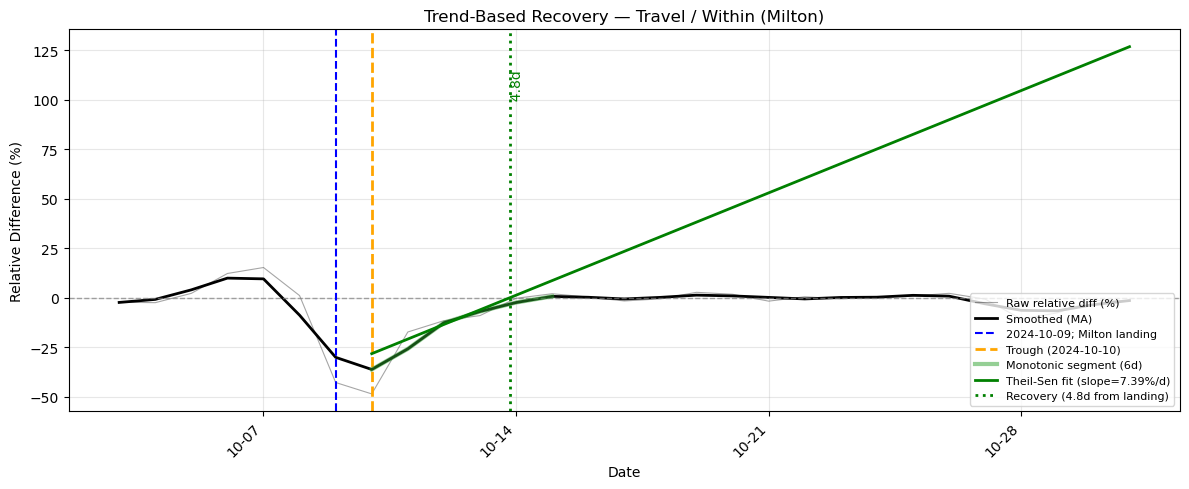


  [within] Category 1: Work & Professional
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      3.8d
  Mono segment len:   6
  Recovery (landing): 4.8d
  Recovery date:      2024-10-13
  Theil-Sen slope:    5.830 %/day
  Slope 95% CI:       [3.620, 7.685] %/day
  Saved: ./recovery_fig/milton_trend_based_region/within/trend_recovery_Work_and_Professional.png


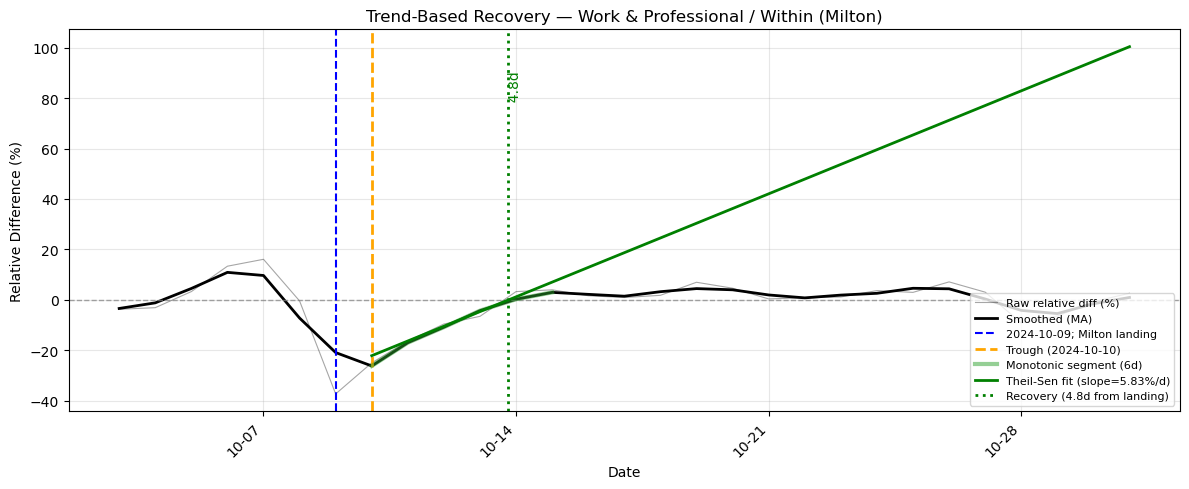


  [within] Category 2: Health
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      3.5d
  Mono segment len:   6
  Recovery (landing): 4.5d
  Recovery date:      2024-10-13
  Theil-Sen slope:    5.535 %/day
  Slope 95% CI:       [2.800, 7.208] %/day
  Saved: ./recovery_fig/milton_trend_based_region/within/trend_recovery_Health.png


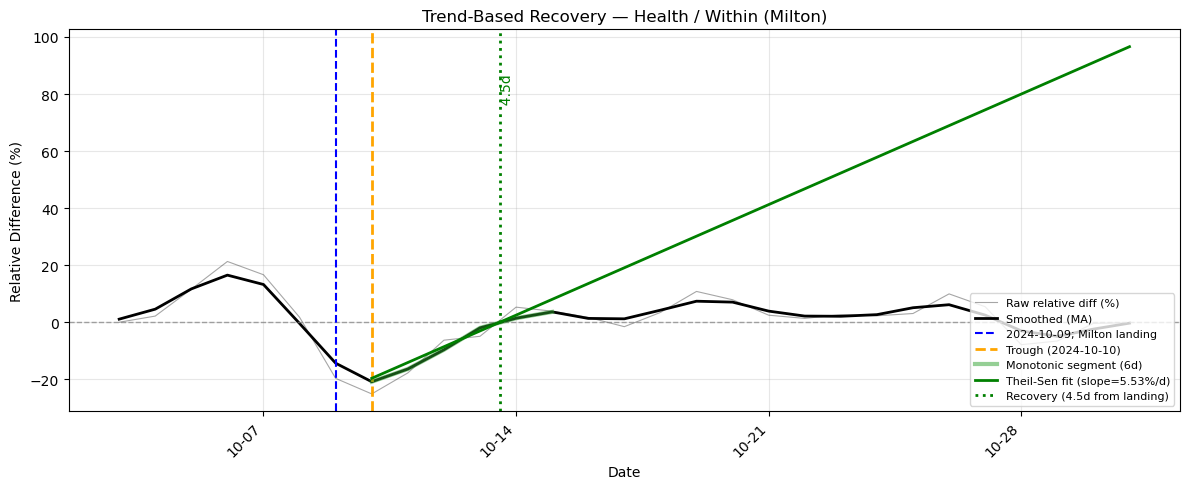


  [within] Category 3: Education
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      5.3d
  Mono segment len:   8
  Recovery (landing): 6.3d
  Recovery date:      2024-10-15
  Theil-Sen slope:    5.536 %/day
  Slope 95% CI:       [4.849, 6.541] %/day
  Saved: ./recovery_fig/milton_trend_based_region/within/trend_recovery_Education.png


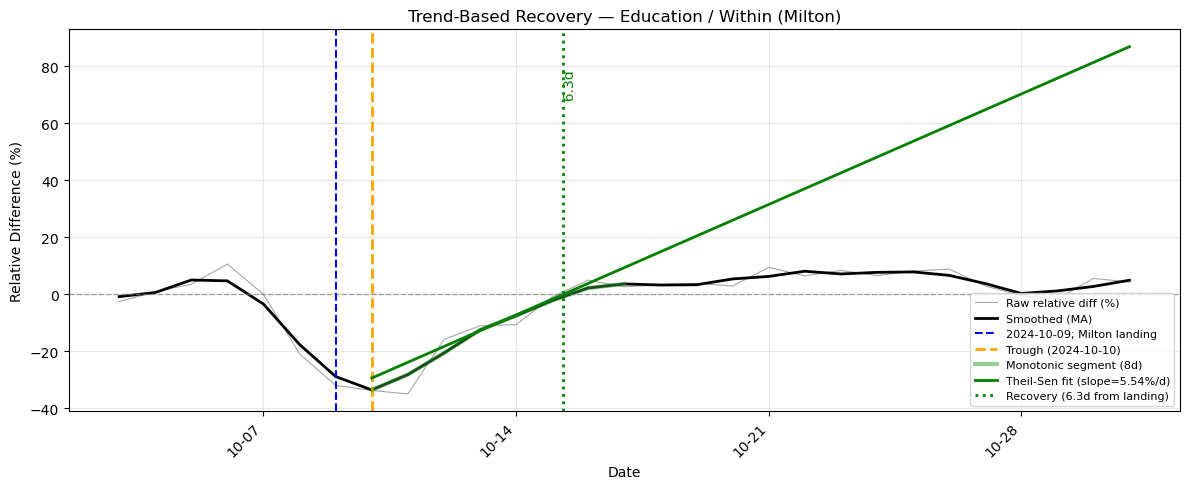


  [within] Category 4: Retail & Leisure
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      4.2d
  Mono segment len:   6
  Recovery (landing): 5.2d
  Recovery date:      2024-10-14
  Theil-Sen slope:    5.720 %/day
  Slope 95% CI:       [4.047, 7.313] %/day
  Saved: ./recovery_fig/milton_trend_based_region/within/trend_recovery_Retail_and_Leisure.png


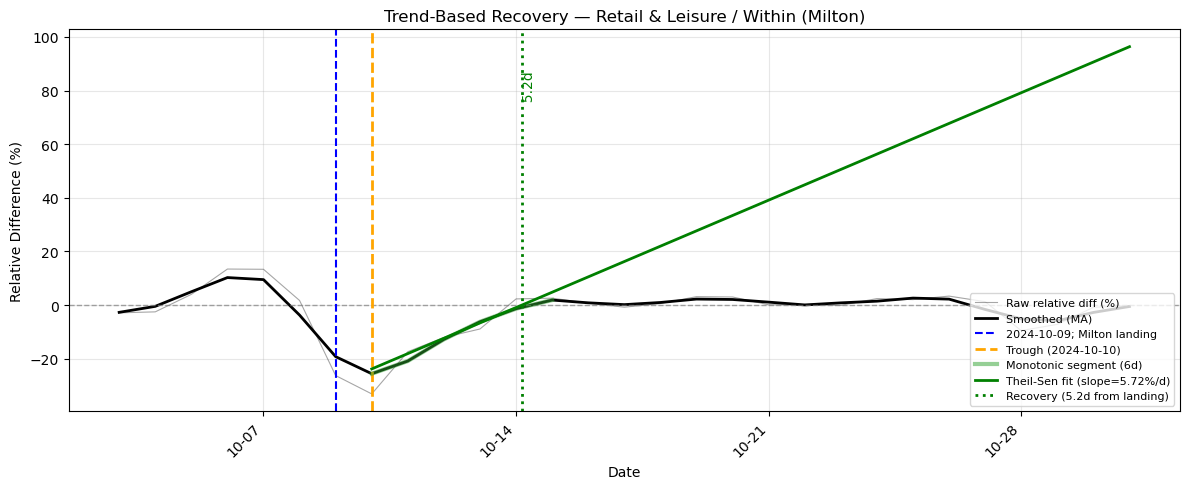


  [within] Category 5: Urban Government
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      3.9d
  Mono segment len:   7
  Recovery (landing): 4.9d
  Recovery date:      2024-10-13
  Theil-Sen slope:    5.329 %/day
  Slope 95% CI:       [2.595, 7.224] %/day
  Saved: ./recovery_fig/milton_trend_based_region/within/trend_recovery_Urban_Government.png


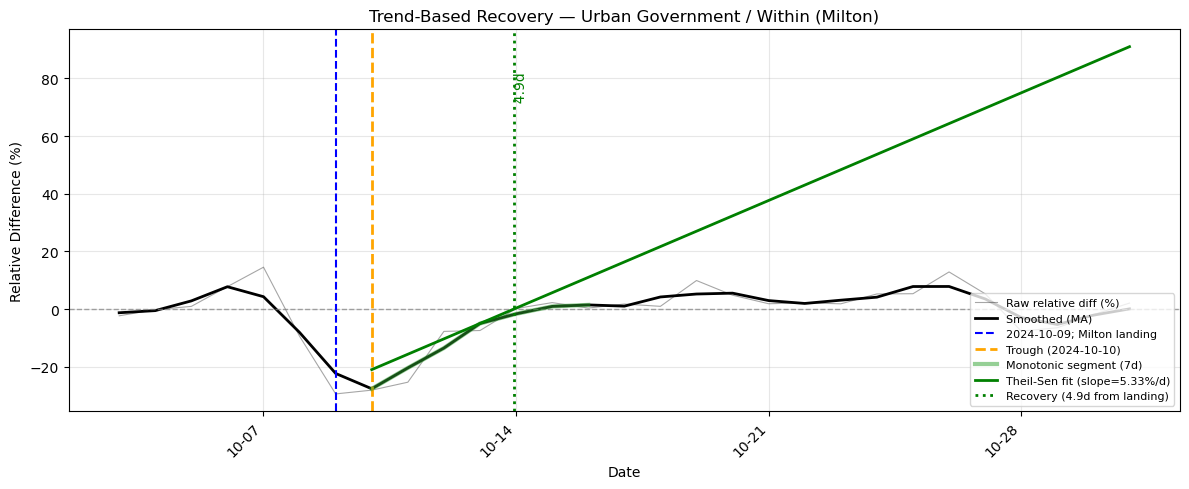


  [within] Category 6: Utilities
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      3.2d
  Mono segment len:   9
  Recovery (landing): 4.2d
  Recovery date:      2024-10-13
  Theil-Sen slope:    9.060 %/day
  Slope 95% CI:       [7.997, 10.700] %/day
  Saved: ./recovery_fig/milton_trend_based_region/within/trend_recovery_Utilities.png


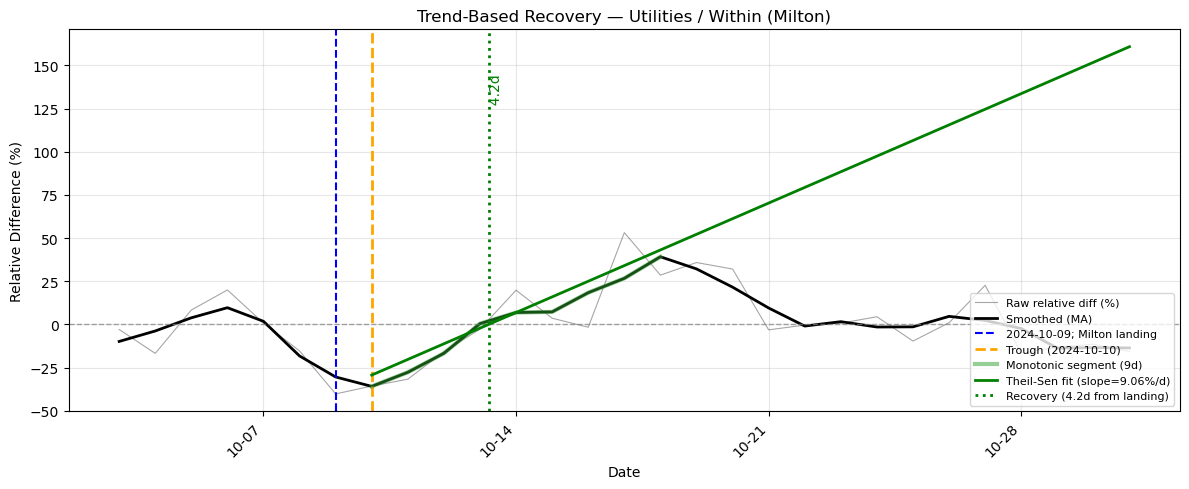


######################################################################
### FLOW TYPE: OUTFLOW
######################################################################

  [outflow] Category 0: Travel
  Trough date:        2024-10-16
  Mono segment len:   N/A
  Recovery (landing): N/A
  Recovery date:      N/A
  Note: Monotonic recovery segment too short for fitting.
  Saved: ./recovery_fig/milton_trend_based_region/outflow/trend_recovery_Travel.png


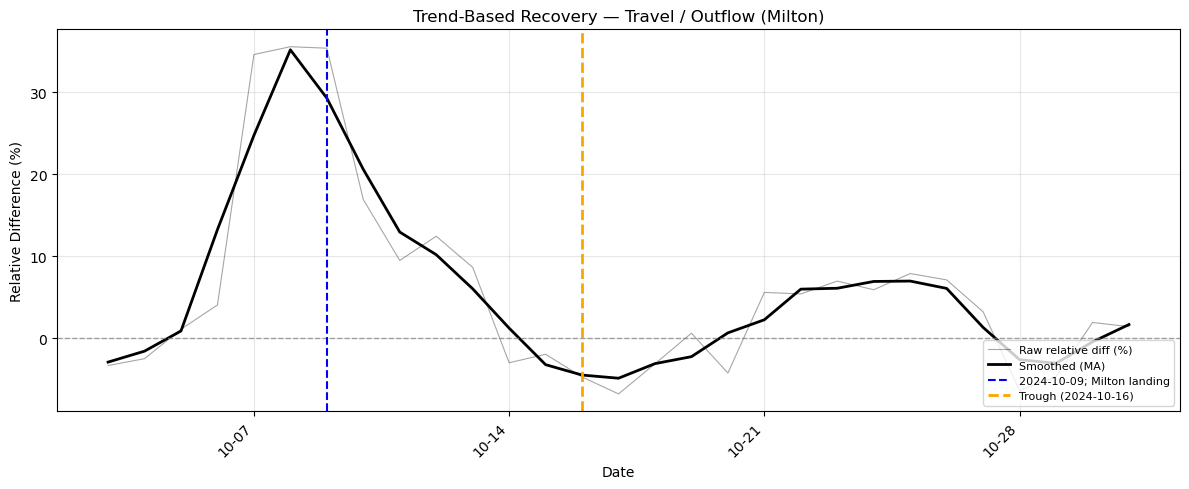


  [outflow] Category 1: Work & Professional
  Trough date:        N/A
  Mono segment len:   N/A
  Recovery (landing): N/A
  Recovery date:      N/A
  Note: No negative deviation found within 7d of landing.
  Saved: ./recovery_fig/milton_trend_based_region/outflow/trend_recovery_Work_and_Professional.png


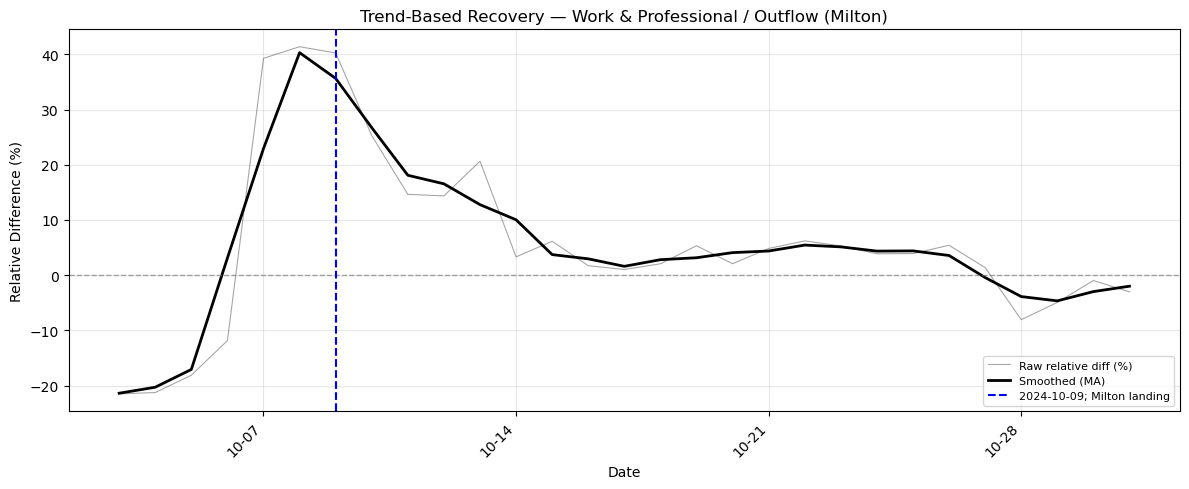


  [outflow] Category 2: Health
  Trough date:        N/A
  Mono segment len:   N/A
  Recovery (landing): N/A
  Recovery date:      N/A
  Note: No negative deviation found within 7d of landing.
  Saved: ./recovery_fig/milton_trend_based_region/outflow/trend_recovery_Health.png


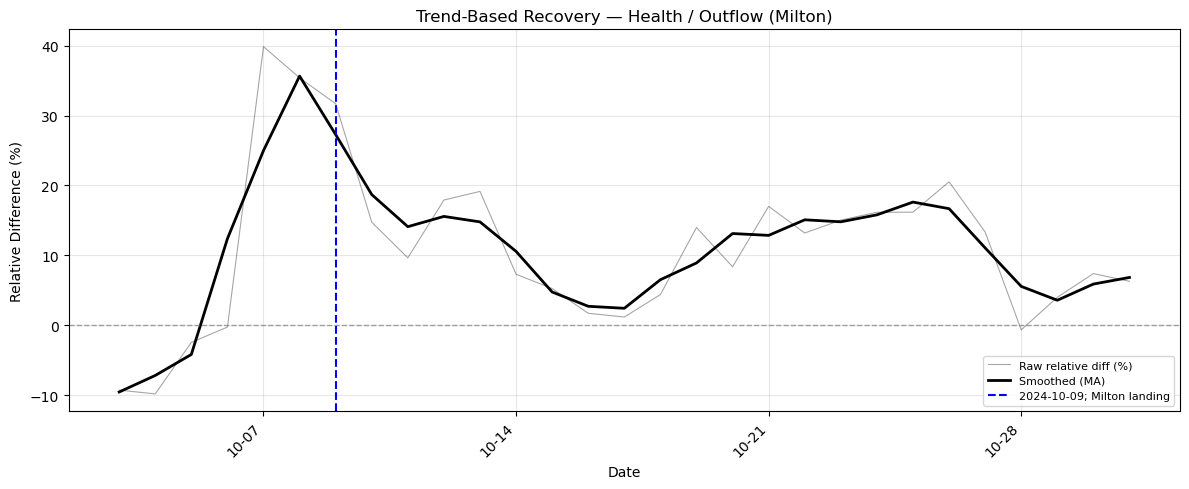


  [outflow] Category 3: Education
  Trough date:        2024-10-16
  Mono segment len:   N/A
  Recovery (landing): N/A
  Recovery date:      N/A
  Note: Monotonic recovery segment too short for fitting.
  Saved: ./recovery_fig/milton_trend_based_region/outflow/trend_recovery_Education.png


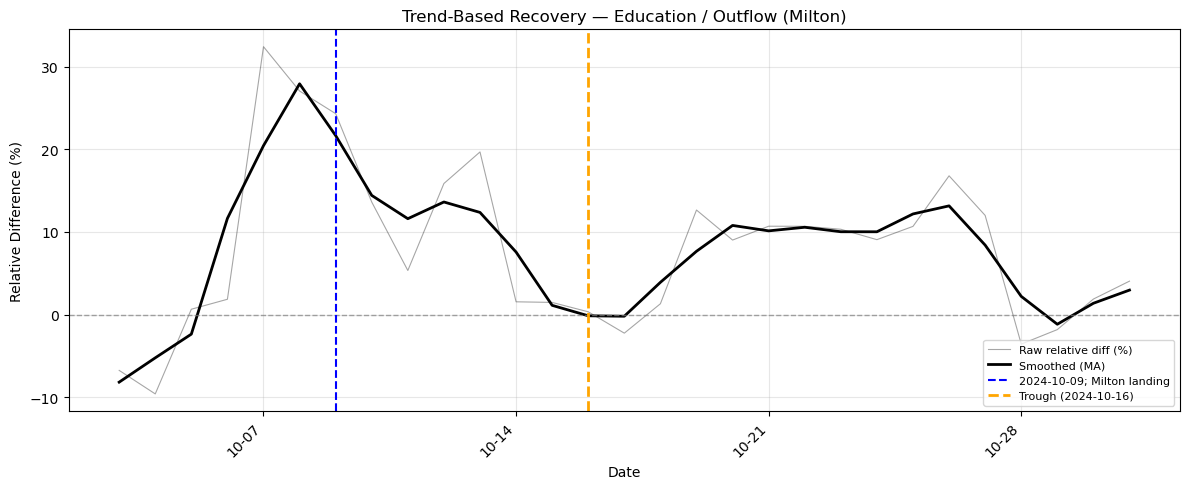


  [outflow] Category 4: Retail & Leisure
  Trough date:        N/A
  Mono segment len:   N/A
  Recovery (landing): N/A
  Recovery date:      N/A
  Note: No negative deviation found within 7d of landing.
  Saved: ./recovery_fig/milton_trend_based_region/outflow/trend_recovery_Retail_and_Leisure.png


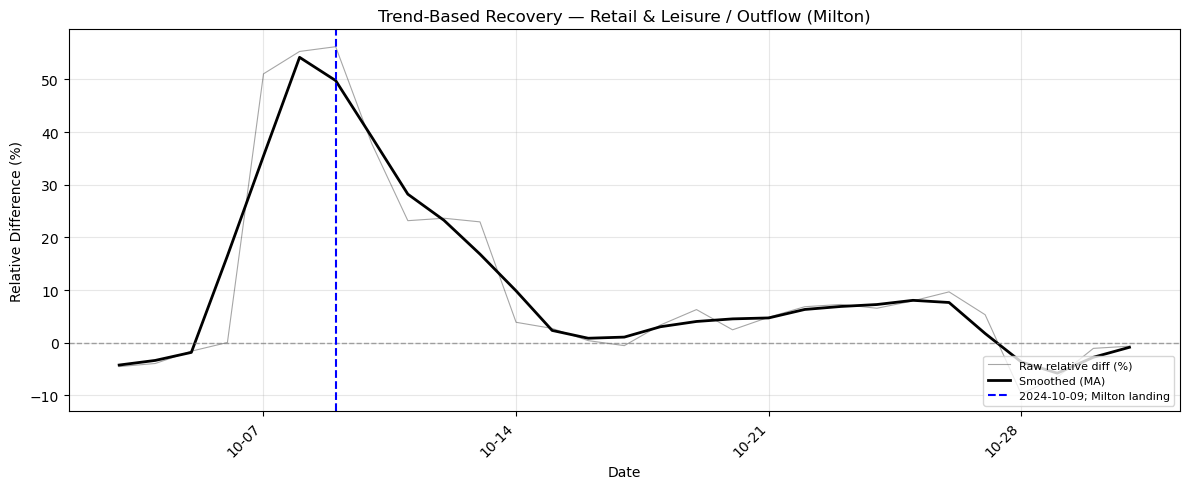


  [outflow] Category 5: Urban Government
  Trough date:        N/A
  Mono segment len:   N/A
  Recovery (landing): N/A
  Recovery date:      N/A
  Note: No negative deviation found within 7d of landing.
  Saved: ./recovery_fig/milton_trend_based_region/outflow/trend_recovery_Urban_Government.png


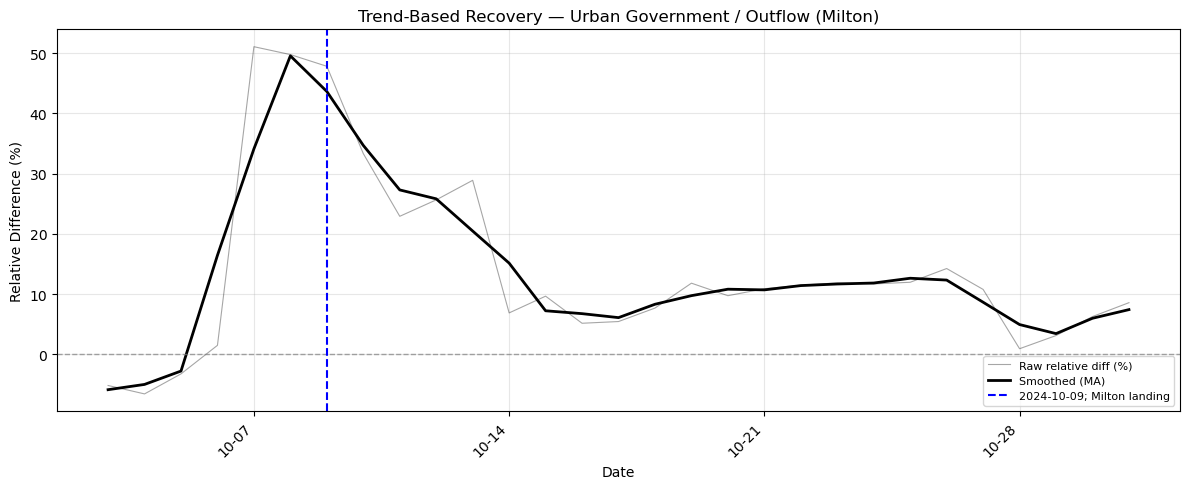


  [outflow] Category 6: Utilities
  Trough date:        N/A
  Mono segment len:   N/A
  Recovery (landing): N/A
  Recovery date:      N/A
  Note: No negative deviation found within 7d of landing.
  Saved: ./recovery_fig/milton_trend_based_region/outflow/trend_recovery_Utilities.png


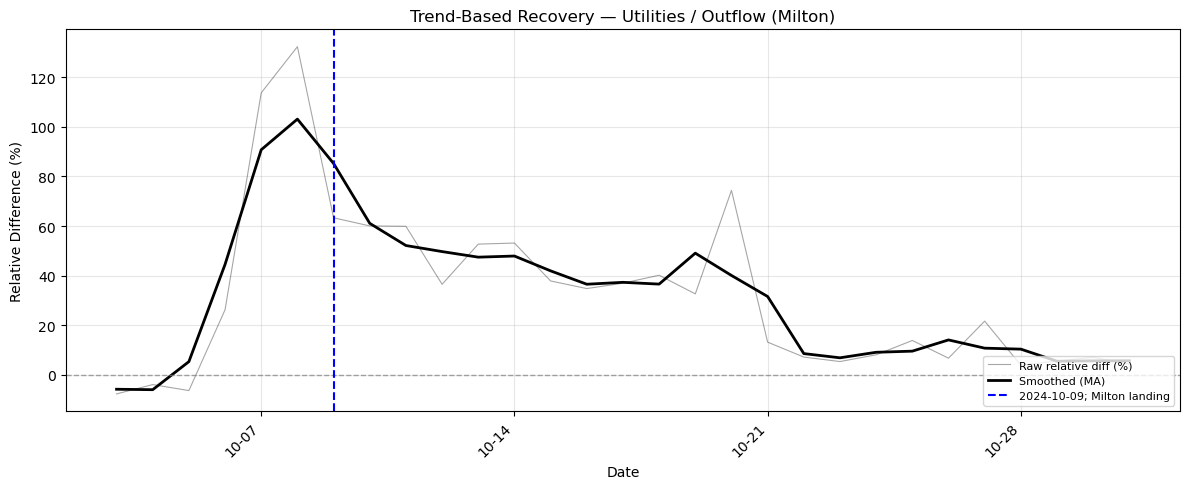


######################################################################
### FLOW TYPE: INFLOW
######################################################################

  [inflow] Category 0: Travel
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      3.8d
  Mono segment len:   6
  Recovery (landing): 4.8d
  Recovery date:      2024-10-13
  Theil-Sen slope:    11.874 %/day
  Slope 95% CI:       [8.056, 16.160] %/day
  Saved: ./recovery_fig/milton_trend_based_region/inflow/trend_recovery_Travel.png


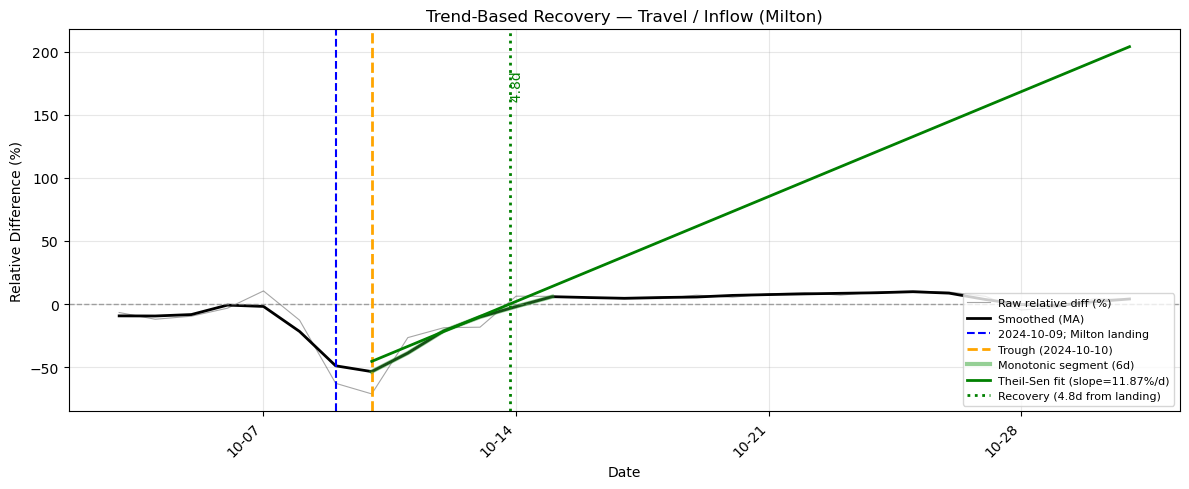


  [inflow] Category 1: Work & Professional
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      4.3d
  Mono segment len:   6
  Recovery (landing): 5.3d
  Recovery date:      2024-10-14
  Theil-Sen slope:    12.413 %/day
  Slope 95% CI:       [4.984, 16.622] %/day
  Saved: ./recovery_fig/milton_trend_based_region/inflow/trend_recovery_Work_and_Professional.png


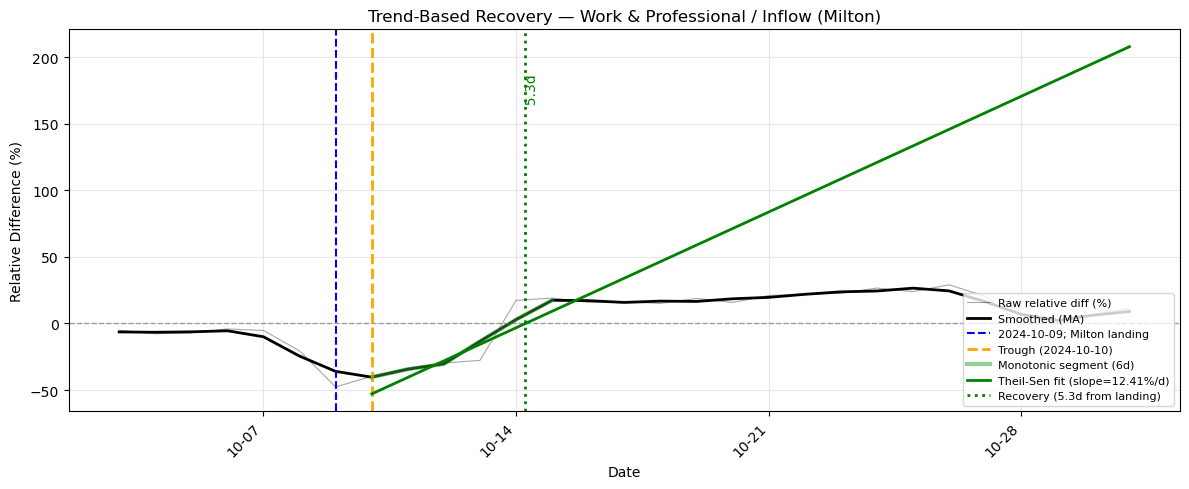


  [inflow] Category 2: Health
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      3.6d
  Mono segment len:   6
  Recovery (landing): 4.6d
  Recovery date:      2024-10-13
  Theil-Sen slope:    9.628 %/day
  Slope 95% CI:       [4.800, 12.315] %/day
  Saved: ./recovery_fig/milton_trend_based_region/inflow/trend_recovery_Health.png


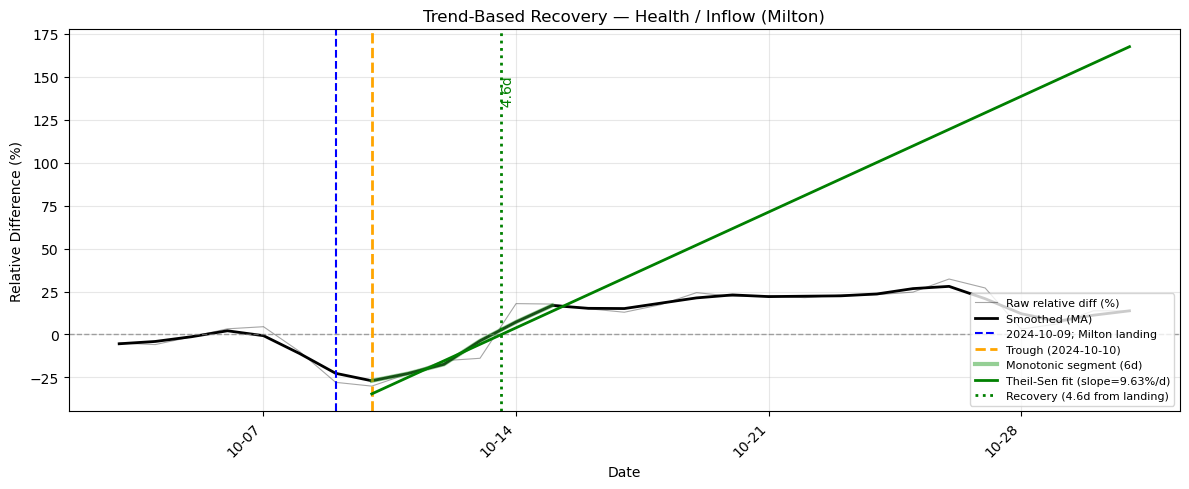


  [inflow] Category 3: Education
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      3.7d
  Mono segment len:   7
  Recovery (landing): 4.7d
  Recovery date:      2024-10-13
  Theil-Sen slope:    9.297 %/day
  Slope 95% CI:       [5.969, 11.169] %/day
  Saved: ./recovery_fig/milton_trend_based_region/inflow/trend_recovery_Education.png


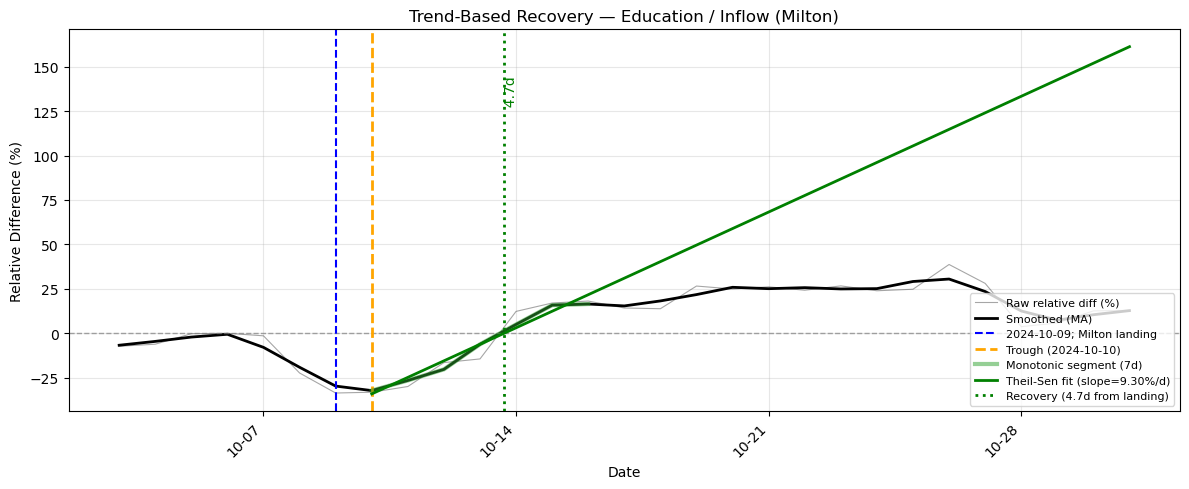


  [inflow] Category 4: Retail & Leisure
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      4.7d
  Mono segment len:   6
  Recovery (landing): 5.7d
  Recovery date:      2024-10-14
  Theil-Sen slope:    10.203 %/day
  Slope 95% CI:       [6.897, 11.318] %/day
  Saved: ./recovery_fig/milton_trend_based_region/inflow/trend_recovery_Retail_and_Leisure.png


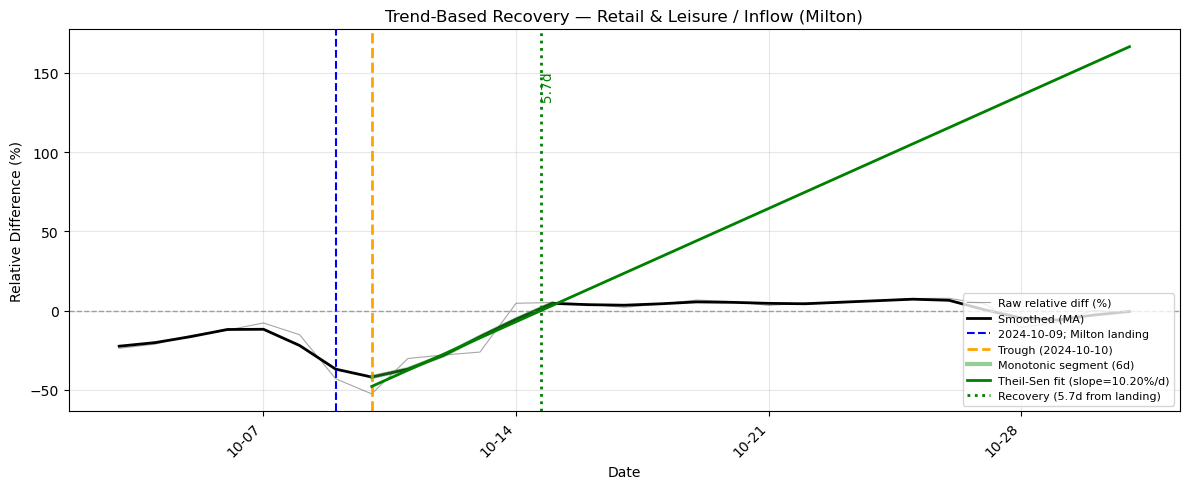


  [inflow] Category 5: Urban Government
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      4.2d
  Mono segment len:   7
  Recovery (landing): 5.2d
  Recovery date:      2024-10-14
  Theil-Sen slope:    11.434 %/day
  Slope 95% CI:       [7.414, 14.565] %/day
  Saved: ./recovery_fig/milton_trend_based_region/inflow/trend_recovery_Urban_Government.png


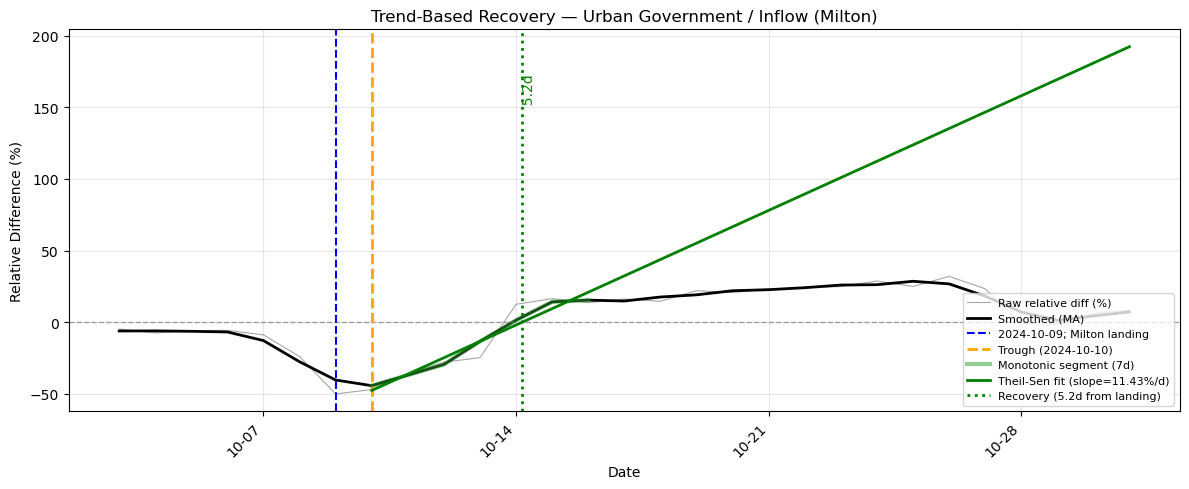


  [inflow] Category 6: Utilities
  Trough date:        2024-10-10
  Landing → trough:   1d
  Trough → zero:      3.1d
  Mono segment len:   9
  Recovery (landing): 4.1d
  Recovery date:      2024-10-13
  Theil-Sen slope:    26.598 %/day
  Slope 95% CI:       [17.206, 30.604] %/day
  Saved: ./recovery_fig/milton_trend_based_region/inflow/trend_recovery_Utilities.png


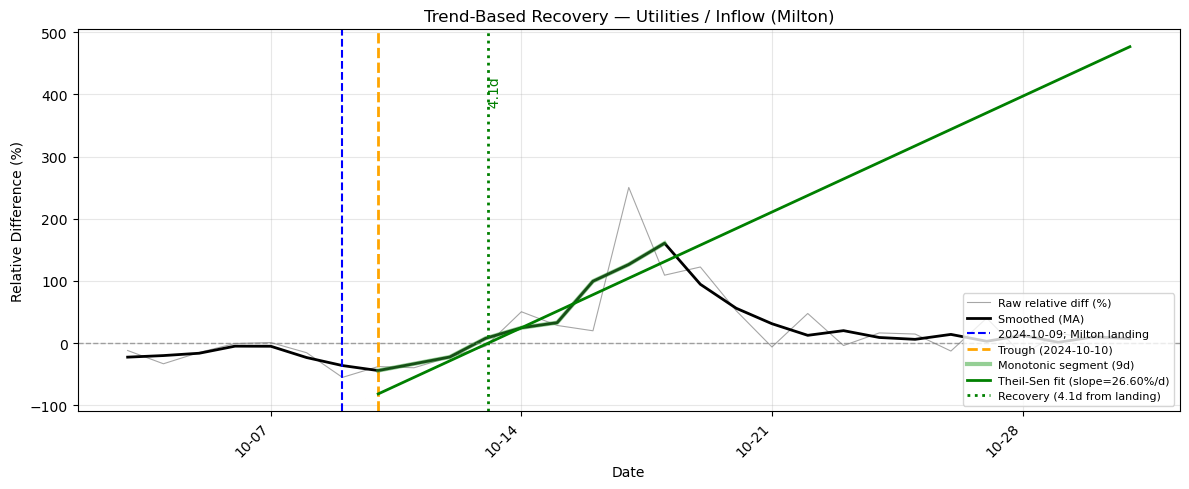

In [10]:
summary_rows = []

for ft_name in FLOW_TYPES:
    print(f"\n{'#'*70}")
    print(f"### FLOW TYPE: {ft_name.upper()}")
    print(f"{'#'*70}")

    ts_array = flow_data[ft_name]  # shape (196, 7)

    for g, cat_name in enumerate(group_names):
        print(f"\n{'='*60}")
        print(f"  [{ft_name}] Category {g}: {cat_name}")
        print(f"{'='*60}")

        # --- 5a. Prepare time series & fit SARIMAX baseline ---
        flow_y = ts_array[:, g]
        y_log, y, X = prepare_time_series_with_exog(flow_y, dates_all)

        try:
            res, y_train, X_train = fit_arimax_model(
                y_log, X,
                order=arima_order, seasonal_order=seasonal_order,
                train_2024_end=train_2024_end,
            )
        except Exception as e:
            print(f"  SARIMAX fit failed: {e}")
            summary_rows.append({
                "flow_type": ft_name, "category": cat_name,
                "trough_date": None, "days_landing_to_trough": None,
                "tau_from_trough": None, "mono_segment_days": None,
                "recovery_days": None, "recovery_date": None,
                "slope_pct_per_day": None, "intercept": None,
            })
            continue

        # --- 5b. Get predictions (adaptive forecast window) ---
        df_rec, forecast_idx = get_predictions_and_ci(
            res, X, y,
            forecast_start=forecast_start, forecast_end=forecast_end,
        )

        # --- 5c. Trend-based recovery (smoothed + monotonic + Theil-Sen) ---
        result = trend_based_recovery(df_rec, landing_date, smooth_window=smooth_window)

        trough   = result["trough_date"]
        rec_days = result["recovery_days"]
        rec_date = result["recovery_date"]
        mono     = result.get("mono_segment")

        print(f"  Trough date:        {trough.date() if trough else 'N/A'}")
        if result.get("days_landing_to_trough") is not None:
            print(f"  Landing → trough:   {result['days_landing_to_trough']}d")
        if result.get("tau_from_trough") is not None:
            print(f"  Trough → zero:      {result['tau_from_trough']:.1f}d")
        print(f"  Mono segment len:   {len(mono) if mono is not None else 'N/A'}")
        if rec_days is not None:
            print(f"  Recovery (landing): {rec_days:.1f}d")
        else:
            print(f"  Recovery (landing): N/A")
        print(f"  Recovery date:      {rec_date.date() if rec_date else 'N/A'}")
        if result.get("slope") is not None:
            print(f"  Theil-Sen slope:    {result['slope']*100:.3f} %/day")
        if result.get("slope_ci"):
            lo, hi = result["slope_ci"]
            print(f"  Slope 95% CI:       [{lo*100:.3f}, {hi*100:.3f}] %/day")
        if result.get("reason"):
            print(f"  Note: {result['reason']}")

        # --- 5d. Plot & save ---
        safe_cat = cat_name.replace(' ', '_').replace('&', 'and')
        save_path = os.path.join(fig_dir, ft_name,
                                 f"trend_recovery_{safe_cat}.png")
        plot_trend_recovery(result, forecast_idx, cat_name, ft_name,
                            hrc_name, landing_date, save_path=save_path)

        # Collect summary
        summary_rows.append({
            "flow_type": ft_name,
            "category": cat_name,
            "trough_date": trough,
            "days_landing_to_trough": result.get("days_landing_to_trough"),
            "tau_from_trough": result.get("tau_from_trough"),
            "mono_segment_days": len(mono) if mono is not None else None,
            "recovery_days": rec_days,
            "recovery_date": rec_date,
            "slope_pct_per_day": result.get("slope", None),
            "intercept": result.get("intercept"),
        })

## 6. Summary Table

In [11]:
df_summary = pd.DataFrame(summary_rows)
df_summary["trough_date"] = df_summary["trough_date"].apply(
    lambda x: x.date() if x is not None else None)
df_summary["recovery_date"] = df_summary["recovery_date"].apply(
    lambda x: x.date() if hasattr(x, "date") else None)
# Express slope as %/day for readability
df_summary["slope_pct_per_day"] = df_summary["slope_pct_per_day"].apply(
    lambda x: round(x * 100, 3) if x is not None else None)
# Round tau columns
df_summary["tau_from_trough"] = df_summary["tau_from_trough"].apply(
    lambda x: round(x, 2) if x is not None else None)
df_summary["recovery_days"] = df_summary["recovery_days"].apply(
    lambda x: round(x, 2) if x is not None else None)

display(df_summary)

# Save to CSV
csv_path = os.path.join(fig_dir, "recovery_summary_3flow.csv")
df_summary.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

,flow_type,category,trough_date,days_landing_to_trough,tau_from_trough,mono_segment_days,recovery_days,recovery_date,slope_pct_per_day,intercept
0,within,Travel,2024-10-10,1.0,3.83,6.0,4.83,2024-10-13,7.390,-0.282813
1,within,Work & Professional,2024-10-10,1.0,3.79,6.0,4.79,2024-10-13,5.830,-0.220881
2,within,Health,2024-10-10,1.0,3.55,6.0,4.55,2024-10-13,5.535,-0.196443
3,within,Education,2024-10-10,1.0,5.31,8.0,6.31,2024-10-15,5.536,-0.294002
4,within,Retail & Leisure,2024-10-10,1.0,4.16,6.0,5.16,2024-10-14,5.720,-0.237805
5,within,Urban Government,2024-10-10,1.0,3.93,7.0,4.93,2024-10-13,5.329,-0.209585
6,within,Utilities,2024-10-10,1.0,3.24,9.0,4.24,2024-10-13,9.060,-0.293803
7,outflow,Travel,2024-10-16,NaN,NaN,NaN,NaN,NaT,NaN,NaN
8,outflow,Work & Professional,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
9,outflow,Health,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN


Saved: ./recovery_fig/milton_trend_based_region/recovery_summary_3flow.csv


## 7. Comparative Bar Charts

Saved: ./recovery_fig/milton_trend_based_region/recovery_time_comparison_within.png


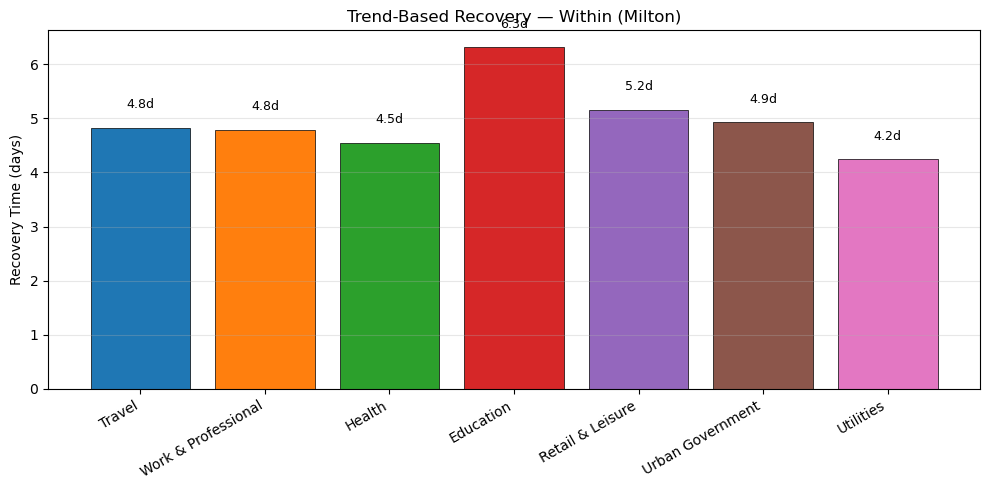

/var/folders/_0/2l3z2qss74scb88wvbv1szxr0000gn/T/ipykernel_1871/9245785.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Saved: ./recovery_fig/milton_trend_based_region/recovery_time_comparison_outflow.png


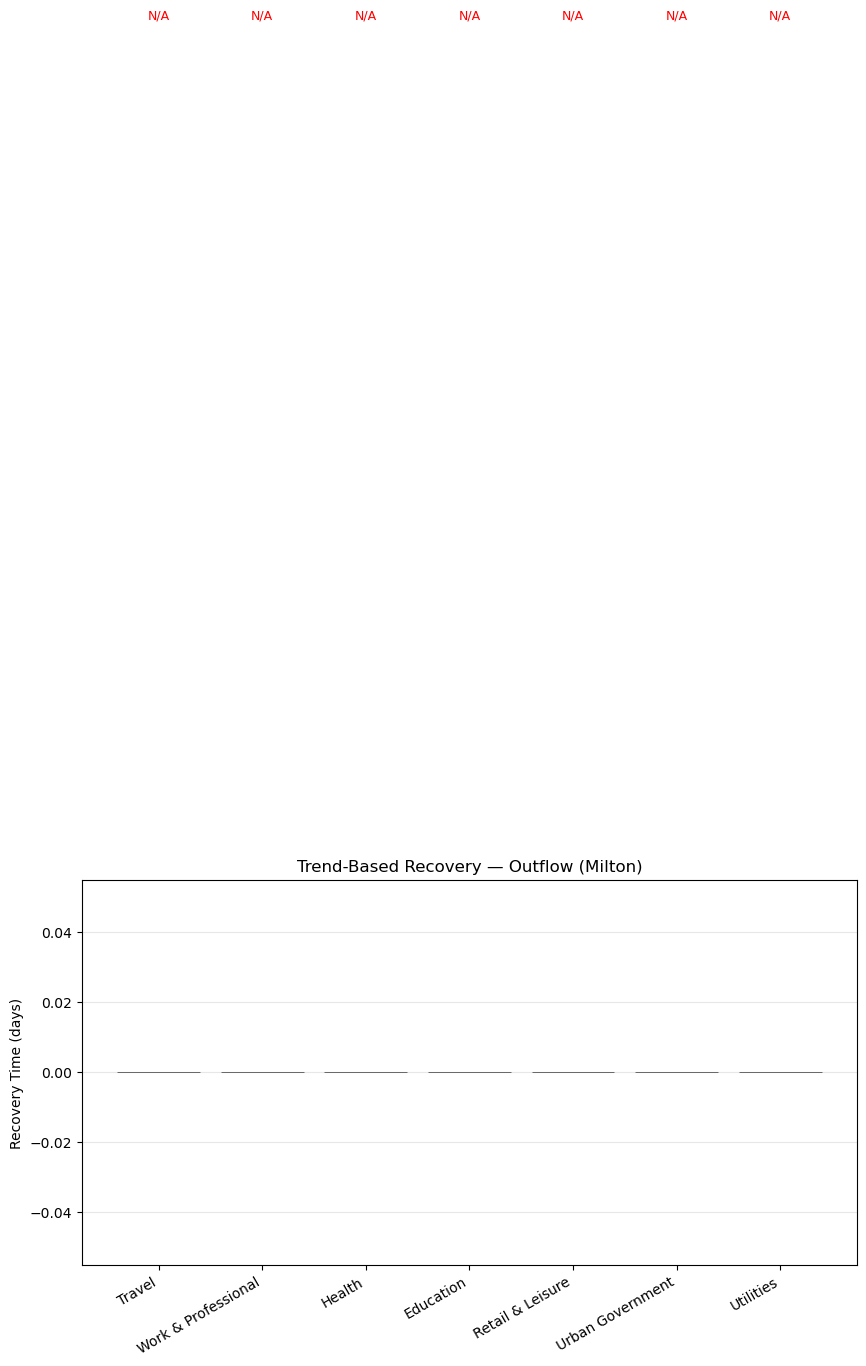

Saved: ./recovery_fig/milton_trend_based_region/recovery_time_comparison_inflow.png


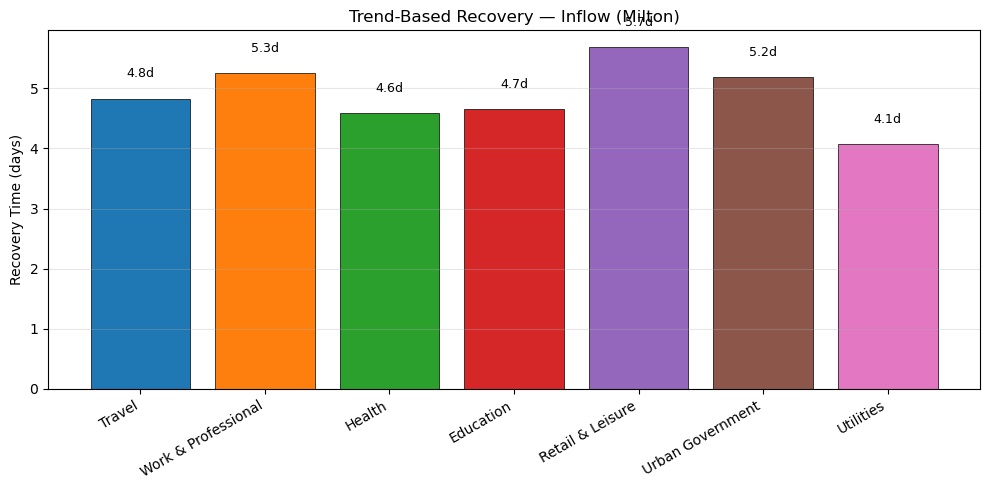

In [12]:
# --- Per-flow-type bar charts (3 separate figures) ---

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
          "#9467bd", "#8c564b", "#e377c2"]

for ft_name in FLOW_TYPES:
    sub = df_summary[df_summary["flow_type"] == ft_name]
    fig, ax = plt.subplots(figsize=(10, 5))

    categories = sub["category"]
    rec_days = sub["recovery_days"].fillna(0)
    x = np.arange(len(categories))

    bars = ax.bar(x, rec_days, color=colors[:len(categories)],
                  edgecolor="black", linewidth=0.5)

    # Label bars
    for bar, val in zip(bars, sub["recovery_days"]):
        if val is not None and not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f"{val:.1f}d", ha="center", va="bottom", fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, 0.3,
                    "N/A", ha="center", va="bottom", fontsize=9, color="red")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, ha="right")
    ax.set_ylabel("Recovery Time (days)")
    ax.set_title(f"Trend-Based Recovery \u2014 {ft_name.capitalize()} ({hrc_name.capitalize()})")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()

    bar_path = os.path.join(fig_dir, f"recovery_time_comparison_{ft_name}.png")
    fig.savefig(bar_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {bar_path}")
    plt.show()

Saved: ./recovery_fig/milton_trend_based_region/recovery_time_comparison_all.png


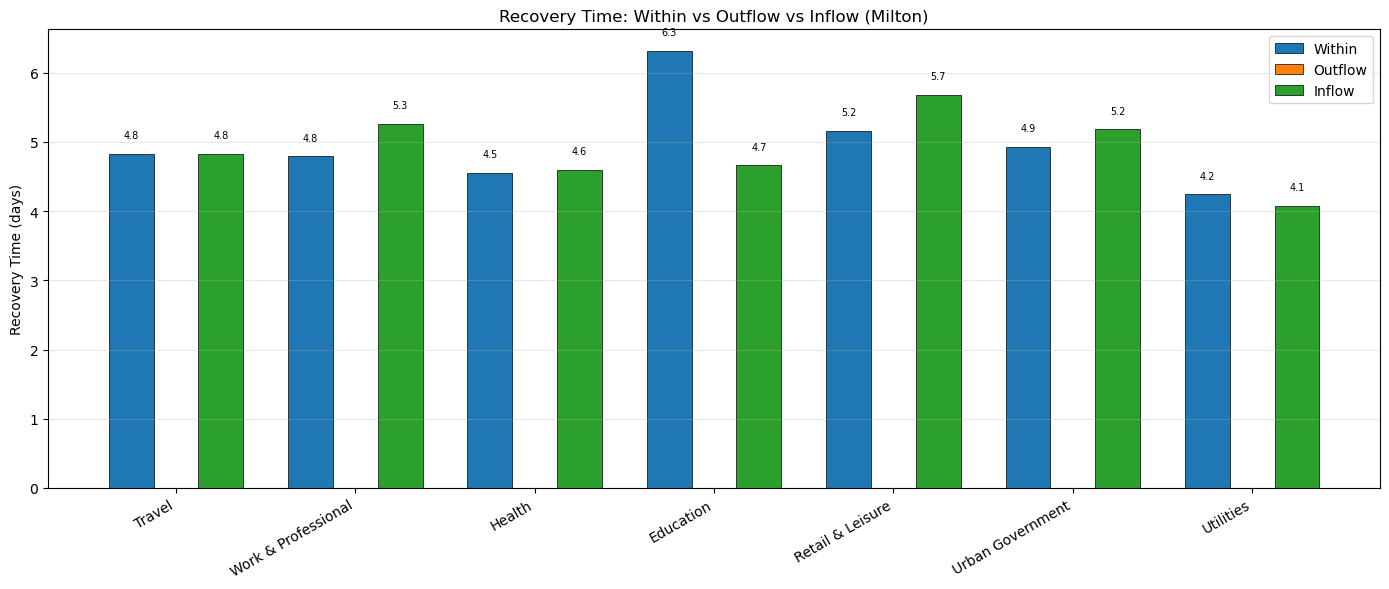

In [13]:
# --- Cross-flow grouped bar chart: Within vs Outflow vs Inflow ---

fig, ax = plt.subplots(figsize=(14, 6))

ft_colors = {"within": "#1f77b4", "outflow": "#ff7f0e", "inflow": "#2ca02c"}
n_ft = len(FLOW_TYPES)
bar_width = 0.25
x = np.arange(n_groups)

for i, ft_name in enumerate(FLOW_TYPES):
    sub = df_summary[df_summary["flow_type"] == ft_name].set_index("category")
    vals = []
    for cat in group_names:
        v = sub.loc[cat, "recovery_days"] if cat in sub.index else None
        if v is None or (isinstance(v, float) and np.isnan(v)):
            vals.append(0)
        else:
            vals.append(float(v))

    offset = (i - n_ft / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, vals, bar_width,
                  label=ft_name.capitalize(), color=ft_colors[ft_name],
                  edgecolor="black", linewidth=0.5)

    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.2,
                    f"{val:.1f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(group_names, rotation=30, ha="right")
ax.set_ylabel("Recovery Time (days)")
ax.set_title(f"Recovery Time: Within vs Outflow vs Inflow ({hrc_name.capitalize()})")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

all_path = os.path.join(fig_dir, "recovery_time_comparison_all.png")
fig.savefig(all_path, dpi=300, bbox_inches="tight")
print(f"Saved: {all_path}")
plt.show()

## 8. Inflow Plots with 2023 Comparison & Population

Re-generates the **inflow** recovery plots with two additions:
1. A **2023 reference line** showing the relative deviation for the same calendar period (Oct 3–31) in 2023, computed from the SARIMAX model's in-sample fitted values.
2. **Total affected-region population** displayed in the plot title.

In [ ]:
# --- Load population for affected counties ---
pop_df = pd.read_csv("acs_socioeconomic_all_counties.csv")
pop_affected = pop_df[pop_df["GEOID"].isin(county_list)]
total_population = pop_affected["total_population"].sum()
print(f"Affected counties: {len(pop_affected)}")
print(f"Total population:  {total_population:,.0f}")


def compute_2023_relative_deviation(y_log, y, res, train_2024_end,
                                     forecast_start, forecast_end):
    """
    Compute relative deviation for Oct 2023 using SARIMAX in-sample fitted values.
    Returns a Series indexed by *2024* dates (shifted +1 year) for overlay plotting.
    """
    # Reconstruct training date mapping (same concat logic as fit_arimax_model)
    y_train_0 = pd.concat([
        y_log.loc["2023-07-31":"2023-10-31"],
        y_log.loc["2024-07-31":train_2024_end],
    ])
    mask = ~y_train_0.isna()
    train_dates = y_train_0[mask].index

    # Map fitted values back to dates
    fitted_log = pd.Series(res.fittedvalues.values, index=train_dates)
    fitted = np.expm1(fitted_log)

    # Corresponding 2023 calendar dates for the 2024 forecast window
    forecast_dates_2024 = pd.date_range(forecast_start, forecast_end, freq="D")
    forecast_dates_2023 = forecast_dates_2024 - pd.DateOffset(years=1)

    # Intersection with available data
    common = forecast_dates_2023.intersection(fitted.index).intersection(
        y.dropna().index
    )

    actual_2023 = y.loc[common]
    fitted_2023 = fitted.loc[common]

    eps = 1e-12
    denom = fitted_2023.replace(0, np.nan) + eps
    rel_dev = (actual_2023 - fitted_2023) / denom

    # Shift to 2024 dates for alignment on the same x-axis
    rel_dev.index = rel_dev.index + pd.DateOffset(years=1)
    return rel_dev

In [ ]:
def plot_trend_recovery_with_2023(result, forecast_idx, category_name, flow_type,
                                  hrc_name, landing_date, rel_dev_2023=None,
                                  total_pop=None, save_path=None):
    """
    Same as plot_trend_recovery but with:
      - 2023 reference line (relative deviation for the same calendar period)
      - Population in the title
    """
    relative_diff = result["relative_diff"]
    rd_smooth     = result["rd_smooth"]
    trough_date   = result["trough_date"]
    recovery_date = result["recovery_date"]
    recovery_days = result["recovery_days"]

    fig, ax = plt.subplots(figsize=(12, 5))

    # --- 2023 reference line ---
    if rel_dev_2023 is not None:
        ax.plot(rel_dev_2023.index, rel_dev_2023.values * 100,
                color="steelblue", linewidth=1.5, linestyle="--", alpha=0.7,
                label="2023 same period")

    # Raw relative difference (thin, faded)
    ax.plot(forecast_idx, relative_diff.reindex(forecast_idx).values * 100,
            color="black", linewidth=0.8, alpha=0.35, label="Raw relative diff (%)")

    # Smoothed relative difference (bold)
    ax.plot(forecast_idx, rd_smooth.reindex(forecast_idx).values * 100,
            color="black", linewidth=2, label="Smoothed (MA)")

    # Zero line
    ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    # Landing date
    ax.axvline(landing_date, color="blue", linestyle="--", linewidth=1.5,
               label=f"{landing_date.date()}; {hrc_name.capitalize()} landing")

    # Trough date
    if trough_date is not None:
        ax.axvline(trough_date, color="orange", linestyle="--", linewidth=2,
                   label=f"Trough ({trough_date.date()})")

    # Highlight monotonic recovery segment
    mono = result.get("mono_segment")
    if mono is not None and len(mono) >= 2:
        ax.plot(mono.index, mono.values * 100,
                color="#2ca02c", linewidth=3, alpha=0.5,
                label=f"Monotonic segment ({len(mono)}d)")

    # Theil-Sen fit line (drawn over the full post-trough range)
    post_trough = result.get("post_trough")
    if post_trough is not None and result["intercept"] is not None:
        a = result["intercept"]
        b = result["slope"]
        t_fit = np.arange(len(post_trough))
        r_fit = a + b * t_fit
        ax.plot(post_trough.index, r_fit * 100,
                color="green", linewidth=2, linestyle="-",
                label=f"Theil-Sen fit (slope={b*100:.2f}%/d)")

    # Recovery date
    if recovery_date is not None:
        ax.axvline(recovery_date, color="green", linestyle=":", linewidth=2,
                   label=f"Recovery ({recovery_days:.1f}d from landing)")
        ax.text(recovery_date, ax.get_ylim()[1] * 0.85,
                f"  {recovery_days:.1f}d", color="green",
                fontsize=10, va="top", ha="left", rotation=90)

    # Title with population
    title = (f"Trend-Based Recovery \u2014 {category_name} / "
             f"{flow_type.capitalize()} ({hrc_name.capitalize()})")
    if total_pop is not None:
        title += f"\nAffected-region population: {total_pop:,.0f}"
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Relative Difference (%)")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    fig.autofmt_xdate(rotation=45)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"  Saved: {save_path}")

    plt.show()

In [ ]:
# --- Re-run inflow analysis with 2023 comparison line ---
ft_name = "inflow"
ts_array = flow_data[ft_name]

for g, cat_name in enumerate(group_names):
    print(f"\n{'='*60}")
    print(f"  [inflow + 2023] Category {g}: {cat_name}")
    print(f"{'='*60}")

    flow_y = ts_array[:, g]
    y_log, y, X = prepare_time_series_with_exog(flow_y, dates_all)

    try:
        res, y_train, X_train = fit_arimax_model(
            y_log, X,
            order=arima_order, seasonal_order=seasonal_order,
            train_2024_end=train_2024_end,
        )
    except Exception as e:
        print(f"  SARIMAX fit failed: {e}")
        continue

    # 2024 predictions
    df_rec, forecast_idx = get_predictions_and_ci(
        res, X, y,
        forecast_start=forecast_start, forecast_end=forecast_end,
    )

    # Trend-based recovery
    result = trend_based_recovery(df_rec, landing_date, smooth_window=smooth_window)

    # 2023 relative deviation (in-sample fitted vs actual)
    rel_dev_2023 = compute_2023_relative_deviation(
        y_log, y, res, train_2024_end, forecast_start, forecast_end
    )

    # Plot with 2023 line and population in title
    safe_cat = cat_name.replace(' ', '_').replace('&', 'and')
    save_path = os.path.join(fig_dir, ft_name,
                             f"trend_recovery_{safe_cat}_with_2023.png")

    plot_trend_recovery_with_2023(
        result, forecast_idx, cat_name, ft_name,
        hrc_name, landing_date,
        rel_dev_2023=rel_dev_2023,
        total_pop=total_population,
        save_path=save_path,
    )